# Thompson Sampling — Twitter Customer Support Dataset

In this notebook we train a Thompson Sampling contextual bandit on a customer service environment
that is modeled after the **Twitter Customer Support dataset** characteristics.

From our EDA we know Twitter support conversations are **short and urgent** — customers come in
frustrated (54.7% inbound complaints) and expect quick resolution. 37% of tweets never even get a response.

So our simulator reflects this: low initial sentiment, high frustration, max 10 turns.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

# importing our customer service environment
from environment import CustomerServiceEnv

print('all imports done!')

all imports done!


## Setting up the Environment

We're using the Twitter profile which has short conversations and frustrated customers.

In [13]:
env = CustomerServiceEnv(dataset='twitter')

print(f'Environment: {env.dataset_name}')
print(f'Max turns per conversation: {env.max_turns}')
print(f'Initial sentiment: {env.initial_sentiment} (0=angry, 1=happy)')
print(f'Initial frustration: {env.initial_frustration}')
print(f'Available actions: {env.ACTIONS}')
print(f'State vector size: {env.get_state_size()} [sentiment, frustration, info_gathered, turn_progress]')

Environment: Twitter Customer Support
Max turns per conversation: 10
Initial sentiment: 0.3 (0=angry, 1=happy)
Initial frustration: 0.6
Available actions: ['ask_info', 'provide_solution', 'empathize', 'escalate', 'close']
State vector size: 4 [sentiment, frustration, info_gathered, turn_progress]


## Running a random episode

Before training anything, lets see what happens when we just pick random actions.
This gives us a baseline to compare against.

In [14]:
# run one episode with random actions
state = env.reset()
total_reward = 0
print('--- Random Agent Episode ---')
print(f'Starting state: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
print()

while not env.done:
    action = random.randint(0, env.NUM_ACTIONS - 1)
    next_state, reward, done, outcome = env.step(action)
    total_reward += reward
    env.render(action)
    state = next_state

print(f'\nTotal reward: {total_reward:.2f}')
print(f'Conversation ended: {outcome}')

--- Random Agent Episode ---
Starting state: sentiment=0.29, frustration=0.47

  Turn  1 | Action: escalate
    Sentiment: 0.29 | Frustration: 0.47 | Info: 0.00
    >> Outcome: escalated

Total reward: -3.10
Conversation ended: escalated


## Thompson Sampling Agent

Thompson Sampling is a contextual bandit algorithm. The idea is simple:
- For each (context, action) pair, maintain a Beta distribution tracking success/failure
- At each step, sample from these distributions and pick the action with highest sample
- This naturally balances exploration vs exploitation

We discretize the state into bins based on sentiment and frustration levels
so the agent can learn different strategies for different customer moods.

In [15]:
class ThompsonSamplingAgent:
    
    def __init__(self, n_actions=5, n_bins=4):
        self.n_actions = n_actions
        self.n_bins = n_bins
        # we discretize sentiment x frustration into bins
        # so total contexts = n_bins * n_bins
        self.n_contexts = n_bins * n_bins
        
        # alpha = successes, beta = failures for each (context, action)
        # start with uniform prior (alpha=1, beta=1)
        self.alpha = np.ones((self.n_contexts, n_actions))
        self.beta_param = np.ones((self.n_contexts, n_actions))
    
    def _get_context(self, state):
        """discretize sentiment and frustration into a context id"""
        sent_bin = min(int(state[0] * self.n_bins), self.n_bins - 1)
        frust_bin = min(int(state[1] * self.n_bins), self.n_bins - 1)
        return sent_bin * self.n_bins + frust_bin
    
    def choose_action(self, state):
        """sample from Beta distributions and pick the best action"""
        ctx = self._get_context(state)
        # thompson sampling: sample from each action's distribution
        samples = np.random.beta(self.alpha[ctx], self.beta_param[ctx])
        return np.argmax(samples)
    
    def update(self, state, action, reward):
        """update the Beta distribution based on reward"""
        ctx = self._get_context(state)
        # normalize reward to roughly [0, 1] for Beta update
        normalized = np.clip((reward + 3) / 8, 0, 1)
        self.alpha[ctx, action] += normalized
        self.beta_param[ctx, action] += (1 - normalized)

print('Thompson Sampling agent defined!')

Thompson Sampling agent defined!


## Training

We'll train the agent for 5000 episodes. Each episode is one customer conversation.
We track rewards, outcomes, and conversation lengths to see if the agent is learning.

In [16]:
# training
agent = ThompsonSamplingAgent(n_actions=env.NUM_ACTIONS, n_bins=4)
num_episodes = 15000

# tracking metrics
all_rewards = []
all_outcomes = []
all_turns = []

for ep in range(num_episodes):
    state = env.reset()
    episode_reward = 0
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        agent.update(state, action, reward)
        episode_reward += reward
        state = next_state
    
    all_rewards.append(episode_reward)
    all_outcomes.append(outcome)
    all_turns.append(env.turn)
    
    # print progress every 1000 episodes
    if (ep + 1) % 3000 == 0:
        recent_rewards = all_rewards[-500:]
        recent_resolved = sum(1 for o in all_outcomes[-500:] if o == 'resolved') / 500
        recent_escalated = sum(1 for o in all_outcomes[-500:] if o == 'escalated') / 500
        print(f'Episode {ep+1}/{num_episodes}')
        print(f'  Avg reward (last 500): {np.mean(recent_rewards):.2f}')
        print(f'  Resolution rate: {recent_resolved:.1%}')
        print(f'  Escalation rate: {recent_escalated:.1%}')
        print(f'  Avg turns: {np.mean(all_turns[-500:]):.1f}')
        print()

print('Training complete!')

Episode 3000/15000
  Avg reward (last 500): -1.37
  Resolution rate: 34.0%
  Escalation rate: 1.8%
  Avg turns: 8.6

Episode 6000/15000
  Avg reward (last 500): -1.32
  Resolution rate: 18.4%
  Escalation rate: 1.2%
  Avg turns: 9.3

Episode 9000/15000
  Avg reward (last 500): -1.25
  Resolution rate: 5.8%
  Escalation rate: 0.0%
  Avg turns: 9.7

Episode 12000/15000
  Avg reward (last 500): -1.10
  Resolution rate: 4.0%
  Escalation rate: 0.0%
  Avg turns: 9.8

Episode 15000/15000
  Avg reward (last 500): -1.17
  Resolution rate: 1.0%
  Escalation rate: 0.4%
  Avg turns: 9.9

Training complete!


## Learning Curve

Plotting the reward over episodes to see if the agent actually learned something.

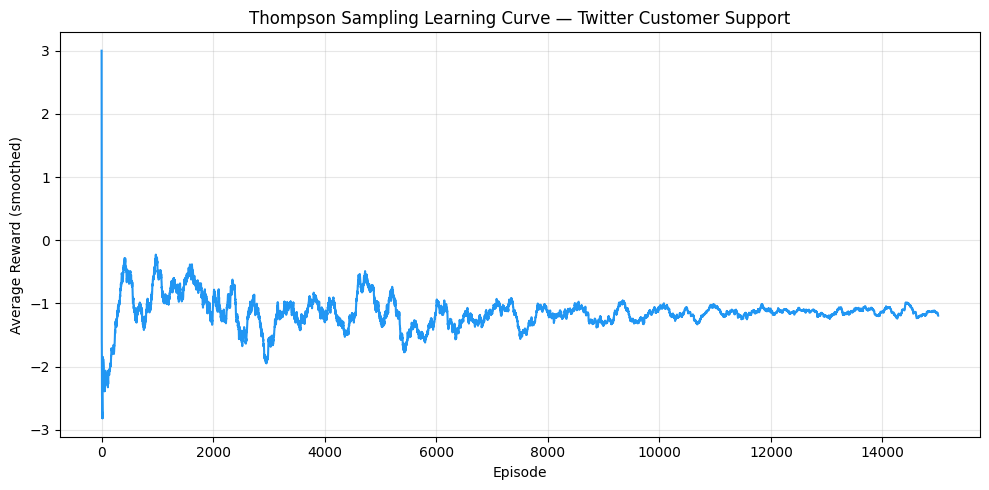

Starting avg reward (first 500): -1.11
Final avg reward (last 500): -1.17


In [17]:
# smoothed learning curve
window = 200
smoothed = [np.mean(all_rewards[max(0,i-window):i+1]) for i in range(len(all_rewards))]

plt.figure(figsize=(10, 5))
plt.plot(smoothed, color='#2196F3', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Average Reward (smoothed)')
plt.title('Thompson Sampling Learning Curve — Twitter Customer Support')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Starting avg reward (first 500): {np.mean(all_rewards[:500]):.2f}')
print(f'Final avg reward (last 500): {np.mean(all_rewards[-500:]):.2f}')

## Resolution Rate Over Time

This is arguably the most important metric — are we actually resolving customer issues?

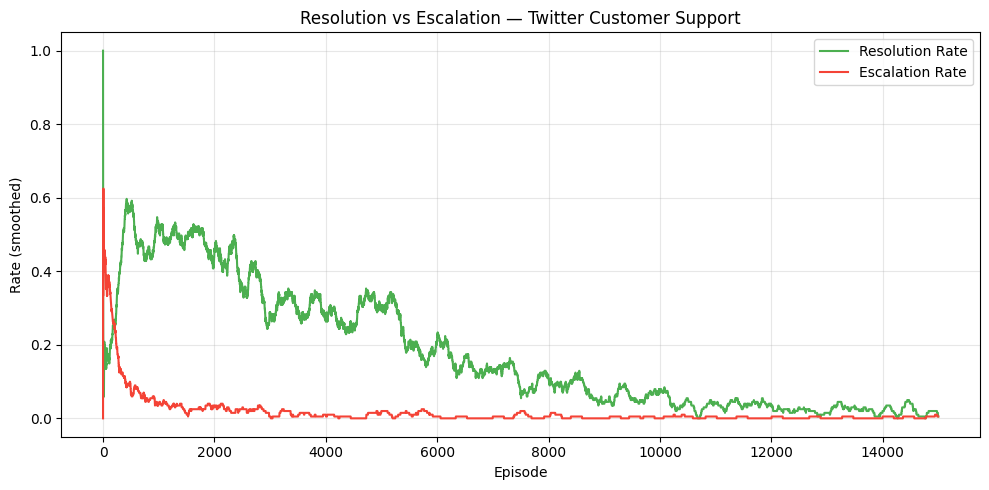

Final resolution rate: 1.0%
Final escalation rate: 0.4%


In [18]:
# resolution rate over time (rolling window)
resolution_flags = [1 if o == 'resolved' else 0 for o in all_outcomes]
escalation_flags = [1 if o == 'escalated' else 0 for o in all_outcomes]

res_smooth = [np.mean(resolution_flags[max(0,i-window):i+1]) for i in range(len(resolution_flags))]
esc_smooth = [np.mean(escalation_flags[max(0,i-window):i+1]) for i in range(len(escalation_flags))]

plt.figure(figsize=(10, 5))
plt.plot(res_smooth, color='#4CAF50', linewidth=1.5, label='Resolution Rate')
plt.plot(esc_smooth, color='#f44336', linewidth=1.5, label='Escalation Rate')
plt.xlabel('Episode')
plt.ylabel('Rate (smoothed)')
plt.title('Resolution vs Escalation — Twitter Customer Support')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final resolution rate: {np.mean(resolution_flags[-500:]):.1%}')
print(f'Final escalation rate: {np.mean(escalation_flags[-500:]):.1%}')

## What Actions did the Agent Learn?

Let's look at which actions the agent prefers in different customer states.
We expect it to learn things like: empathize when frustration is high, provide solution when enough info is gathered.

In [19]:
# test what actions the agent picks in different situations
test_scenarios = [
    {'name': 'Angry customer, no info', 'state': [0.2, 0.8, 0.1, 0.1]},
    {'name': 'Calm customer, no info', 'state': [0.7, 0.2, 0.1, 0.1]},
    {'name': 'Angry customer, lots of info', 'state': [0.2, 0.8, 0.8, 0.3]},
    {'name': 'Calm customer, lots of info', 'state': [0.7, 0.2, 0.8, 0.3]},
    {'name': 'Neutral, halfway through', 'state': [0.5, 0.5, 0.5, 0.5]},
]

print('What the agent would do in different situations:')
print('=' * 60)
for scenario in test_scenarios:
    state = np.array(scenario['state'])
    # run multiple samples to see the distribution
    action_counts = np.zeros(env.NUM_ACTIONS)
    for _ in range(1000):
        a = agent.choose_action(state)
        action_counts[a] += 1
    action_counts /= 1000
    
    print(f"\n{scenario['name']}:")
    for i, action_name in enumerate(env.ACTIONS):
        bar = '#' * int(action_counts[i] * 40)
        print(f'  {action_name:18s} {action_counts[i]:.1%} {bar}')

What the agent would do in different situations:

Angry customer, no info:
  ask_info           14.2% #####
  provide_solution   12.5% #####
  empathize          73.2% #############################
  escalate           0.1% 
  close              0.0% 

Calm customer, no info:
  ask_info           22.1% ########
  provide_solution   8.9% ###
  empathize          68.4% ###########################
  escalate           0.1% 
  close              0.5% 

Angry customer, lots of info:
  ask_info           14.2% #####
  provide_solution   13.8% #####
  empathize          71.9% ############################
  escalate           0.0% 
  close              0.1% 

Calm customer, lots of info:
  ask_info           22.2% ########
  provide_solution   8.4% ###
  empathize          69.1% ###########################
  escalate           0.1% 
  close              0.2% 

Neutral, halfway through:
  ask_info           6.1% ##
  provide_solution   1.2% 
  empathize          92.7% ##########################

## Action Distribution Plot

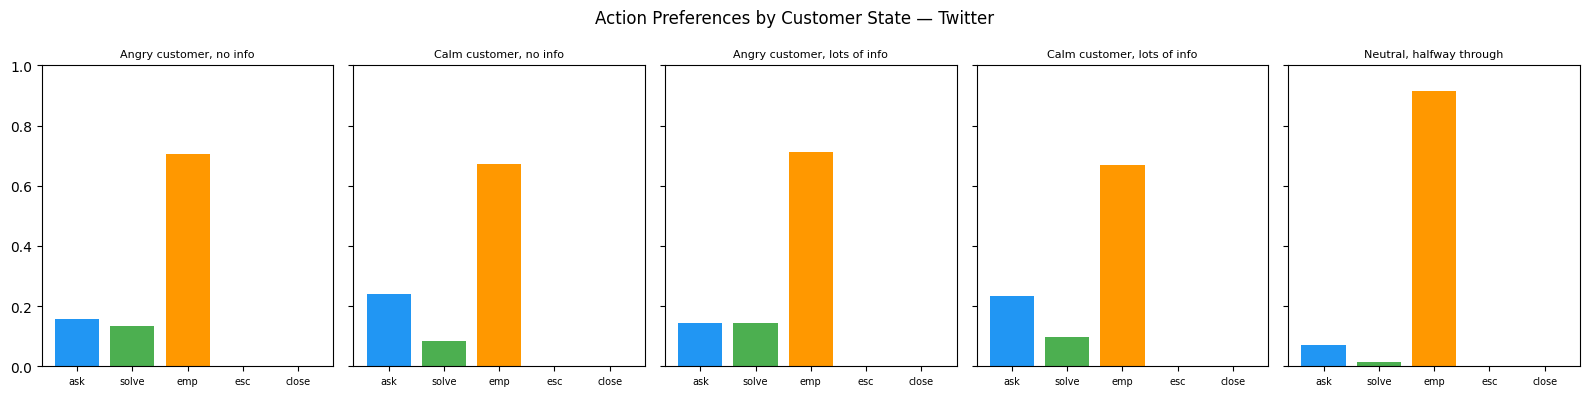

In [20]:
# bar chart of action preferences per scenario
fig, axes = plt.subplots(1, len(test_scenarios), figsize=(16, 4), sharey=True)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#f44336', '#9C27B0']

for idx, scenario in enumerate(test_scenarios):
    state = np.array(scenario['state'])
    action_counts = np.zeros(env.NUM_ACTIONS)
    for _ in range(1000):
        a = agent.choose_action(state)
        action_counts[a] += 1
    action_counts /= 1000
    
    axes[idx].bar(range(env.NUM_ACTIONS), action_counts, color=colors)
    axes[idx].set_title(scenario['name'], fontsize=8)
    axes[idx].set_xticks(range(env.NUM_ACTIONS))
    axes[idx].set_xticklabels(['ask', 'solve', 'emp', 'esc', 'close'], fontsize=7)
    axes[idx].set_ylim(0, 1)

fig.suptitle('Action Preferences by Customer State — Twitter', fontsize=12)
plt.tight_layout()
plt.show()

## Observations

*TODO: Write your observations here after running the notebook. Some things to think about:*
- *Did the resolution rate improve over training?*
- *What strategy did the agent learn for angry vs calm customers?*
- *Does the agent avoid unnecessary escalations?*

## Testing the Trained Agent

Lets watch the trained agent handle a few customer conversations step by step.

In [21]:
# watch the trained agent handle 3 conversations
print('='*60)
print('TESTING THE TRAINED AGENT — 3 sample conversations')
print('='*60)

for test_ep in range(3):
    state = env.reset()
    total_reward = 0
    print(f'\n--- Conversation {test_ep+1} ---')
    print(f'Customer arrives: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        total_reward += reward
        
        action_name = env.ACTIONS[action]
        print(f'  Turn {env.turn}: Agent chose [{action_name}] -> reward={reward:.2f}, sentiment={next_state[0]:.2f}')
        state = next_state
    
    print(f'  Result: {outcome} | Total reward: {total_reward:.2f} | Turns: {env.turn}')

TESTING THE TRAINED AGENT — 3 sample conversations

--- Conversation 1 ---
Customer arrives: sentiment=0.27, frustration=0.59
  Turn 1: Agent chose [empathize] -> reward=0.10, sentiment=0.42
  Turn 2: Agent chose [empathize] -> reward=0.10, sentiment=0.57
  Turn 3: Agent chose [empathize] -> reward=0.10, sentiment=0.72
  Turn 4: Agent chose [empathize] -> reward=0.10, sentiment=0.87
  Turn 5: Agent chose [empathize] -> reward=0.10, sentiment=1.00
  Turn 6: Agent chose [empathize] -> reward=0.10, sentiment=1.00
  Turn 7: Agent chose [empathize] -> reward=0.10, sentiment=1.00
  Turn 8: Agent chose [empathize] -> reward=0.10, sentiment=1.00
  Turn 9: Agent chose [empathize] -> reward=0.10, sentiment=1.00
  Turn 10: Agent chose [empathize] -> reward=-1.90, sentiment=1.00
  Result: abandoned | Total reward: -1.00 | Turns: 10

--- Conversation 2 ---
Customer arrives: sentiment=0.16, frustration=0.66
  Turn 1: Agent chose [ask_info] -> reward=0.00, sentiment=0.16
  Turn 2: Agent chose [empath

## Final Summary Stats

In [22]:
# run 500 test episodes and get clean stats
test_rewards = []
test_outcomes = {'resolved': 0, 'escalated': 0, 'abandoned': 0}
test_turns = []

for _ in range(500):
    state = env.reset()
    ep_reward = 0
    while not env.done:
        action = agent.choose_action(state)
        state, reward, done, outcome = env.step(action)
        ep_reward += reward
    test_rewards.append(ep_reward)
    test_outcomes[outcome] += 1
    test_turns.append(env.turn)

print('='*50)
print('FINAL EVALUATION (500 test episodes)')
print('='*50)
print(f'Average reward:     {np.mean(test_rewards):.2f}')
print(f'Resolution rate:    {test_outcomes["resolved"]/500:.1%}')
print(f'Escalation rate:    {test_outcomes["escalated"]/500:.1%}')
print(f'Abandonment rate:   {test_outcomes["abandoned"]/500:.1%}')
print(f'Avg conversation:   {np.mean(test_turns):.1f} turns')
print('='*50)

FINAL EVALUATION (500 test episodes)
Average reward:     -1.16
Resolution rate:    1.4%
Escalation rate:    0.2%
Abandonment rate:   98.4%
Avg conversation:   9.9 turns
